# 🔬 Breast Cancer Wisconsin — Data Cleaning & Exploratory Analysis
---
This notebook loads the Breast Cancer Wisconsin dataset, cleans it, explores its structure,
and generates a comprehensive set of visualisations comparing **Malignant (M)** vs **Benign (B)** tumours.


## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── Aesthetics
PALETTE  = {"M": "#E63946", "B": "#457B9D"}
COLORS   = list(PALETTE.values())
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "#F8F9FA"})

legend_patches = [Patch(color=PALETTE["M"], label="Malignant"),
                  Patch(color=PALETTE["B"], label="Benign")]

print("✓ Libraries loaded")

✓ Libraries loaded


## 2. Load Data

In [4]:
df = pd.read_csv(r"C:\Users\EDEDA001\Desktop\Data Analysis🍪🪨\PortFolio Build\breast cancer summary.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Data Cleaning
Steps:
- Drop the `id` column (non-informative identifier)
- Encode `diagnosis` as an ordered categorical variable
- Confirm zero nulls and zero duplicates
- Export cleaned CSV


In [6]:
print(df.columns)

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [7]:


# Encode diagnosis
df["diagnosis"] = pd.Categorical(df["diagnosis"], categories=["B", "M"], ordered=True)

# Check nulls
print("Null values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# Feature groups
mean_cols  = [c for c in df.columns if c.endswith("_mean")]
se_cols    = [c for c in df.columns if c.endswith("_se")]
worst_cols = [c for c in df.columns if c.endswith("_worst")]

print(f"\n✓ Clean dataset: {len(df)} rows, {len(df.columns)} columns")
print(f"  Mean features  : {len(mean_cols)}")
print(f"  SE features    : {len(se_cols)}")
print(f"  Worst features : {len(worst_cols)}")

Null values per column:
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Duplicate rows: 0

✓ Clean dataset: 569 rows, 31 columns
  Mean

## 4. Summary Statistics

In [8]:
df.describe().T.style.background_gradient(cmap="Blues", subset=["mean", "std"])

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
texture_mean,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
perimeter_mean,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
area_mean,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
smoothness_mean,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
compactness_mean,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
concavity_mean,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
concave points_mean,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
symmetry_mean,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000
fractal_dimension_mean,569.000000,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.097440


In [9]:
# Class breakdown
counts = df["diagnosis"].value_counts()
print("Diagnosis Counts:")
print(counts.to_string())
print(f"\nMalignant : {counts['M']} ({counts['M']/len(df)*100:.1f}%)")
print(f"Benign    : {counts['B']} ({counts['B']/len(df)*100:.1f}%)")

Diagnosis Counts:
diagnosis
B    357
M    212

Malignant : 212 (37.3%)
Benign    : 357 (62.7%)


## 5. Diagnosis Distribution

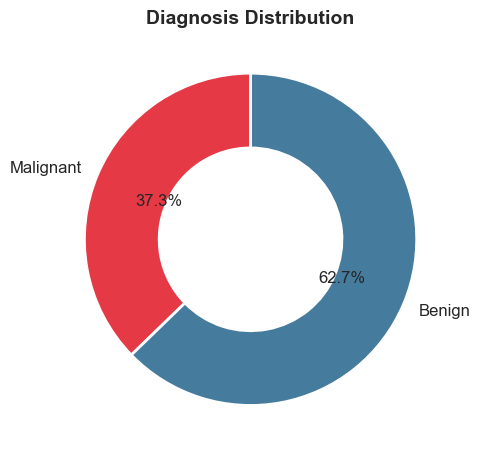

In [10]:
fig, ax = plt.subplots(figsize=(5, 5))
counts_plot = df["diagnosis"].value_counts().reindex(["M", "B"])
wedge_props = dict(width=0.45, edgecolor="white", linewidth=2)
ax.pie(counts_plot, labels=["Malignant", "Benign"], colors=COLORS,
       autopct="%1.1f%%", startangle=90,
       wedgeprops=wedge_props, textprops={"fontsize": 12})
ax.set_title("Diagnosis Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. KDE Distributions — Key Mean Features

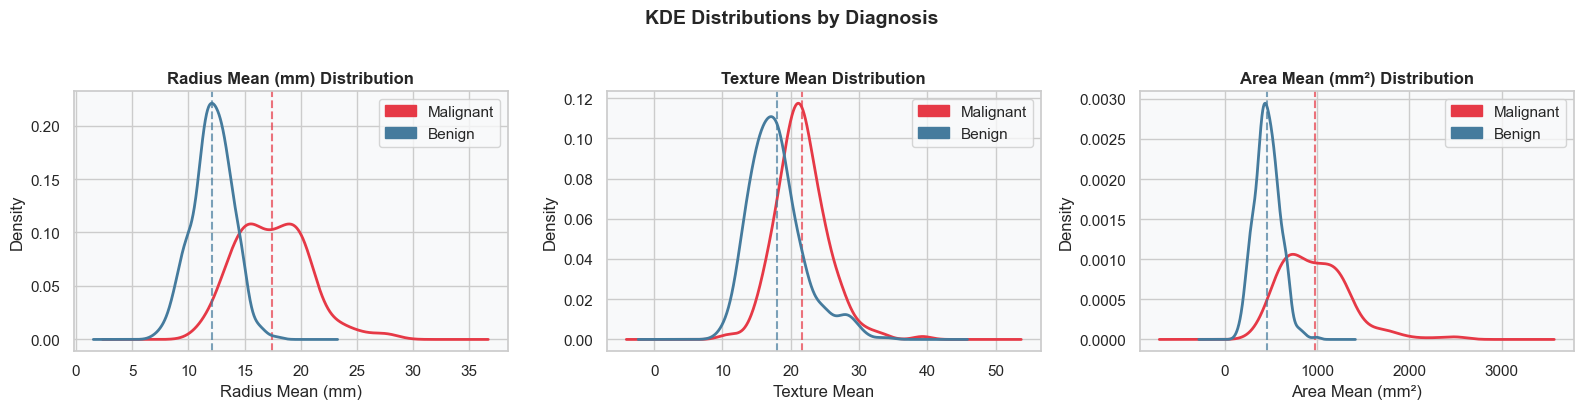

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
features = ["radius_mean", "texture_mean", "area_mean"]
titles   = ["Radius Mean (mm)", "Texture Mean", "Area Mean (mm²)"]

for ax, feat, title in zip(axes, features, titles):
    for dx, col in PALETTE.items():
        subset = df[df["diagnosis"] == dx][feat]
        subset.plot.kde(ax=ax, color=col, linewidth=2, label=dx)
        ax.axvline(subset.mean(), color=col, linestyle="--", alpha=0.7)
    ax.set_xlabel(title)
    ax.set_title(f"{title} Distribution", fontweight="bold")
    ax.legend(handles=legend_patches)

fig.suptitle("KDE Distributions by Diagnosis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 7. Boxplots — Key Mean Features by Diagnosis

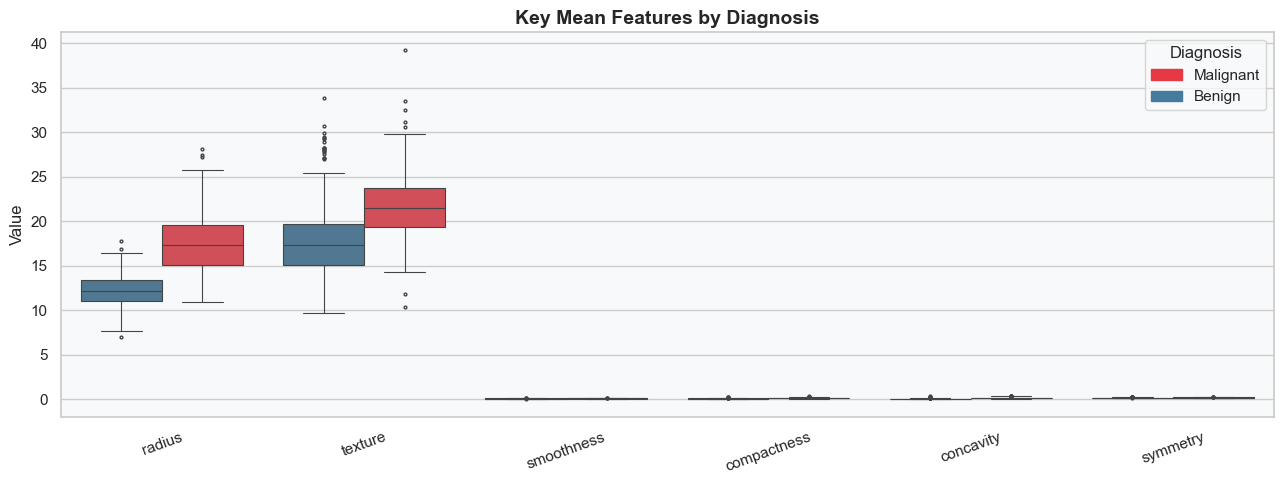

In [12]:
key_feats = ["radius_mean", "texture_mean", "smoothness_mean",
             "compactness_mean", "concavity_mean", "symmetry_mean"]

plot_df = df[["diagnosis"] + key_feats].melt(id_vars="diagnosis",
                                              var_name="Feature", value_name="Value")
plot_df["Feature"] = plot_df["Feature"].str.replace("_mean", "", regex=False)

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=plot_df, x="Feature", y="Value", hue="diagnosis",
            palette=PALETTE, ax=ax, linewidth=0.8, fliersize=2)
ax.set_title("Key Mean Features by Diagnosis", fontsize=14, fontweight="bold")
ax.set_xlabel(""); ax.tick_params(axis="x", rotation=20)
ax.legend(handles=legend_patches, title="Diagnosis")
plt.tight_layout()
plt.show()

## 8. Violin Plots — Concave Points & Symmetry

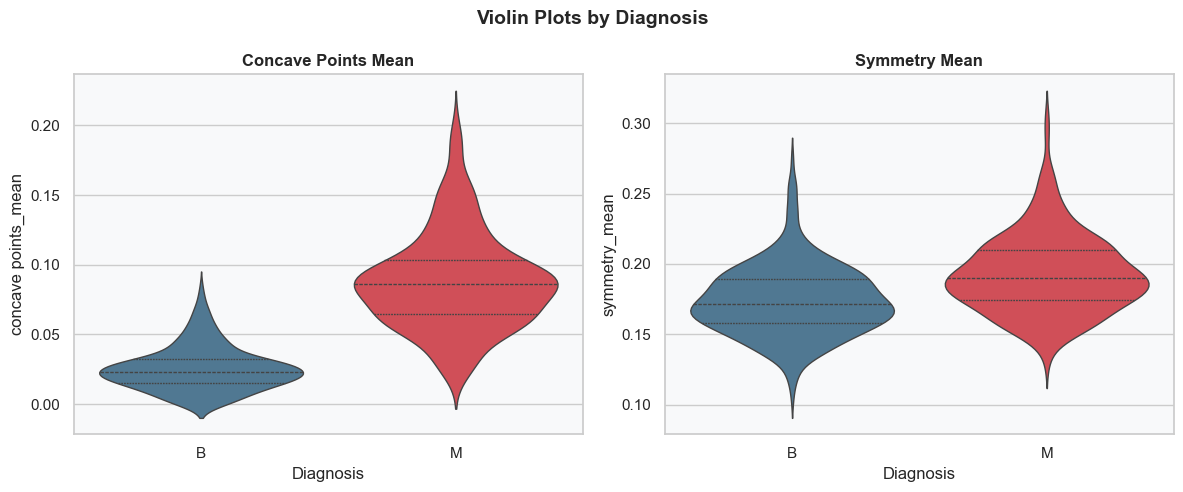

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
violin_feats = ["concave points_mean", "symmetry_mean"]
violin_titles = ["Concave Points Mean", "Symmetry Mean"]

for ax, feat, title in zip(axes, violin_feats, violin_titles):
    sns.violinplot(data=df, x="diagnosis", y=feat, hue="diagnosis",
                   palette=PALETTE, ax=ax, inner="quartile",
                   linewidth=1, legend=False)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Diagnosis")

fig.suptitle("Violin Plots by Diagnosis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Scatter Plots

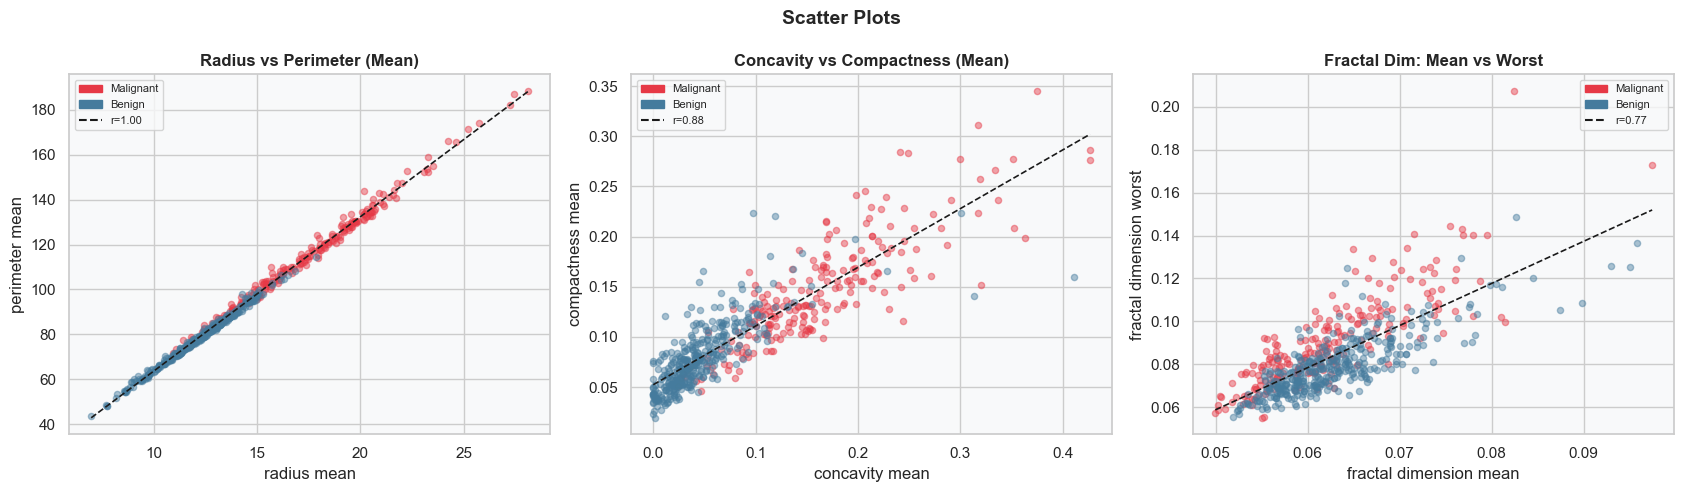

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

scatter_pairs = [
    ("radius_mean",           "perimeter_mean",      "Radius vs Perimeter (Mean)"),
    ("concavity_mean",        "compactness_mean",     "Concavity vs Compactness (Mean)"),
    ("fractal_dimension_mean","fractal_dimension_worst","Fractal Dim: Mean vs Worst"),
]

for ax, (x, y, title) in zip(axes, scatter_pairs):
    for dx, col in PALETTE.items():
        sub = df[df["diagnosis"] == dx]
        ax.scatter(sub[x], sub[y], color=col, alpha=0.45, s=20, label=dx)
    # Regression line
    m, b, r, *_ = stats.linregress(df[x], df[y])
    x_line = np.linspace(df[x].min(), df[x].max(), 100)
    ax.plot(x_line, m * x_line + b, "k--", linewidth=1.2, label=f"r={r:.2f}")
    ax.set_xlabel(x.replace("_", " ")); ax.set_ylabel(y.replace("_", " "))
    ax.set_title(title, fontweight="bold")
    ax.legend(handles=legend_patches + [plt.Line2D([0],[0],color="k",ls="--",label=f"r={r:.2f}")],
              fontsize=8)

fig.suptitle("Scatter Plots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Correlation Heatmap — Mean Features

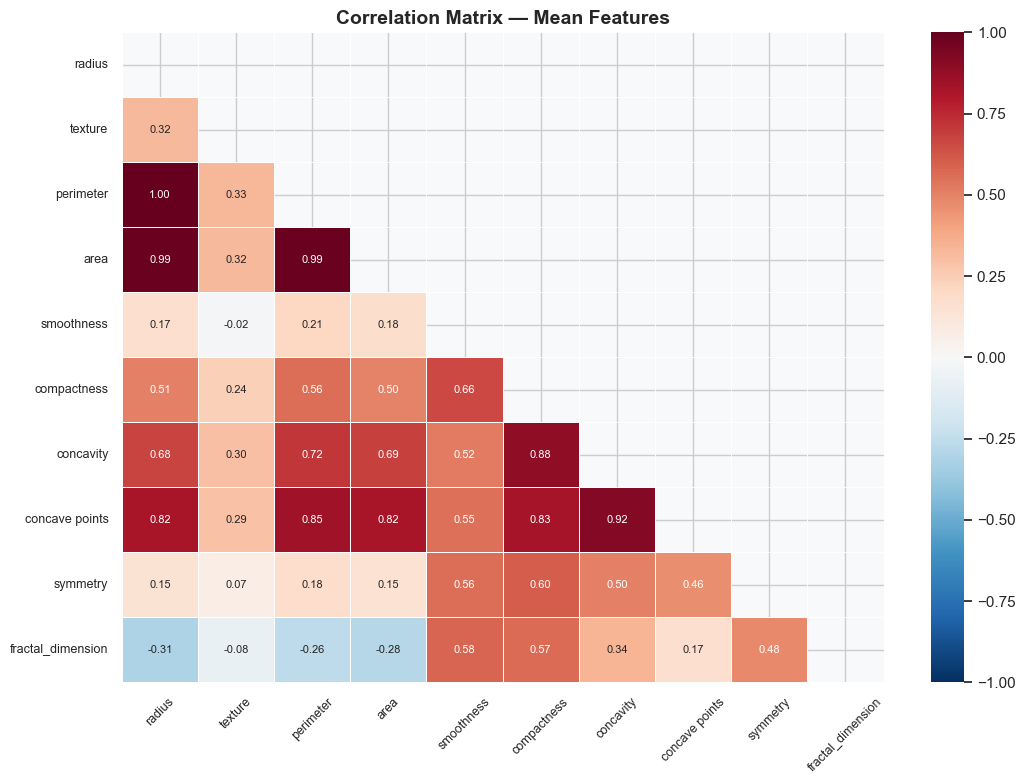

In [15]:
corr = df[mean_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
short_labels = [c.replace("_mean", "") for c in mean_cols]

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.4, annot=True, fmt=".2f",
            annot_kws={"size": 8},
            xticklabels=short_labels, yticklabels=short_labels)
ax.set_title("Correlation Matrix — Mean Features", fontsize=14, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()

## 11. Mean vs Worst Feature Comparison — Radius

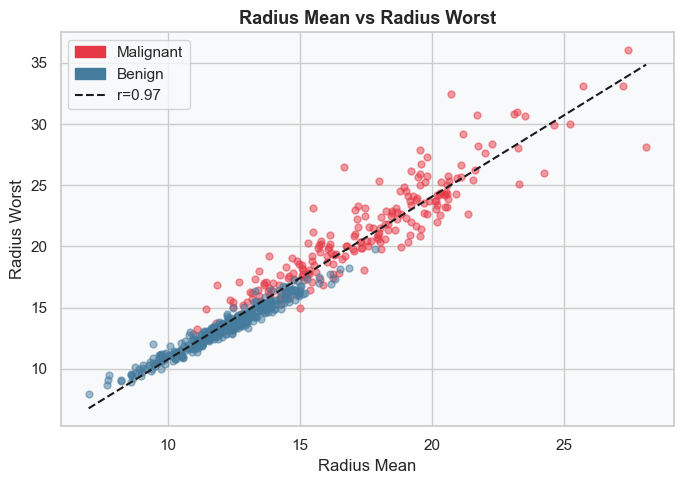

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
for dx, col in PALETTE.items():
    sub = df[df["diagnosis"] == dx]
    ax.scatter(sub["radius_mean"], sub["radius_worst"],
               color=col, alpha=0.5, s=25, label=dx)
m, b, r, *_ = stats.linregress(df["radius_mean"], df["radius_worst"])
x_line = np.linspace(df["radius_mean"].min(), df["radius_mean"].max(), 100)
ax.plot(x_line, m * x_line + b, "k--", linewidth=1.5, label=f"r = {r:.3f}")
ax.set_xlabel("Radius Mean"); ax.set_ylabel("Radius Worst")
ax.set_title("Radius Mean vs Radius Worst", fontsize=13, fontweight="bold")
ax.legend(handles=legend_patches + [plt.Line2D([0],[0],color="k",ls="--",label=f"r={r:.2f}")])
plt.tight_layout()
plt.show()

## 12. Normalized Feature Profiles — Mean & Worst

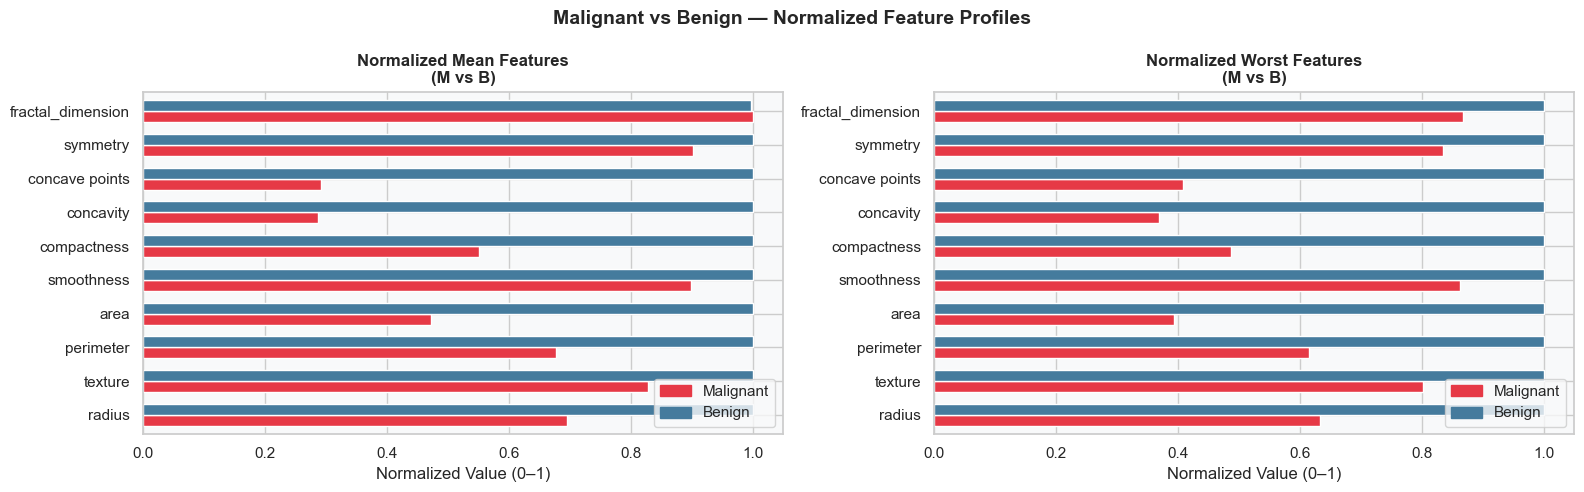

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, cols, title in zip(axes,
                             [mean_cols, worst_cols],
                             ["Mean Features", "Worst Features"]):
    avg = df.groupby("diagnosis")[cols].mean()
    avg.columns = [c.replace("_mean","").replace("_worst","") for c in cols]
    avg_norm = avg.div(avg.max())
    avg_norm.T.plot(kind="barh", color=COLORS, ax=ax, legend=False, width=0.65)
    ax.set_title(f"Normalized {title}\n(M vs B)", fontweight="bold")
    ax.set_xlabel("Normalized Value (0–1)")
    ax.legend(handles=legend_patches)

fig.suptitle("Malignant vs Benign — Normalized Feature Profiles",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 13. Top Features Correlated with Diagnosis

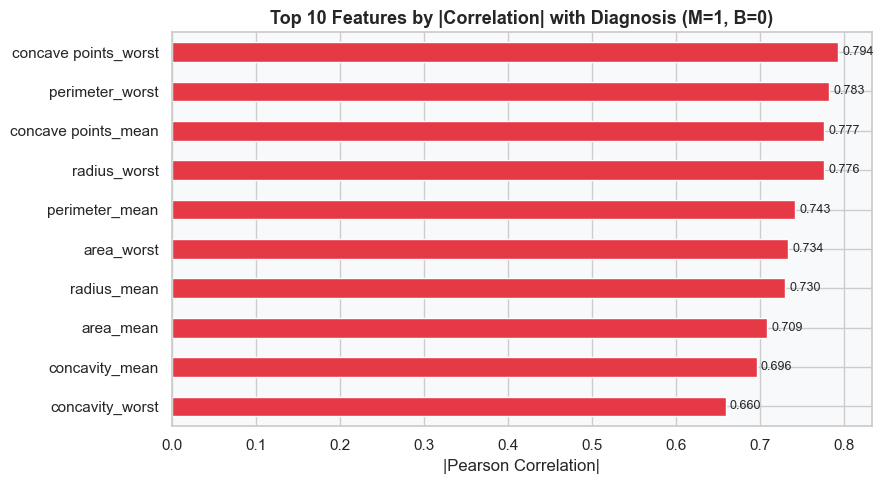


Top 10 features:
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610


In [18]:
df2 = df.copy()
df2["label"] = (df2["diagnosis"] == "M").astype(int)
corr_label = df2.drop(columns=["diagnosis","label"]).corrwith(df2["label"]).abs()
top10 = corr_label.nlargest(10)

fig, ax = plt.subplots(figsize=(9, 5))
top10.sort_values().plot(kind="barh", color="#E63946", ax=ax, edgecolor="white")
ax.set_title("Top 10 Features by |Correlation| with Diagnosis (M=1, B=0)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("|Pearson Correlation|")
for bar, val in zip(ax.patches, top10.sort_values().values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(top10.to_string())

## 14. Export Cleaned Dataset

In [20]:
df.to_csv(r"C:\Users\EDEDA001\Desktop\Data Analysis🍪🪨\PortFolio Build\breast cancer summary2.csv", index=False)
print(f"✓ Cleaned CSV exported: {len(df)} rows × {len(df.columns)} columns")

✓ Cleaned CSV exported: 569 rows × 31 columns
